# Animal10: EDA

#TODO

confusion matrix prelozit

resnet too heavy

weighted test acc

pozriet co je bottleneck pri treningu


## 1. Importy a nastavenie prostredia

V tejto časti načítame knižnice, nastavíme seed pre reprodukovateľnosť a pripravíme si jednoduché vizuálne nastavenia grafov.

In [49]:


import hashlib
from pathlib import Path
import random
import sys
import warnings
import os
import wandb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler


from torchvision import transforms, models
from torchvision.models import (
    ResNet18_Weights,
)

from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score

from dotenv import load_dotenv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from PIL import Image
from sklearn.model_selection import train_test_split

from animal10_dataset import Animal10Dataset

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)


## 2. Načítanie cesty k datasetu a preklad názvov tried

Tu si pripravíme cestu k datasetu a použijeme vstavaný súbor `archive/translate.py`.

Dataset používa talianske názvy priečinkov (`cane`, `gatto`, `ragno`, ...), ale pre EDA je praktickejšie zobrazovať aj anglický ekvivalent. Preto slovník z `translate.py` načítame a upravíme do mapovania `taliančina -> angličtina`.


In [50]:
DATA_ROOT = Path("dataset_utils/raw-img")

from dataset_utils.translate import translate as raw_translate

class_dirs = sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()])

# Z `translate.py` vytvoríme smer taliančina -> angličtina.
# V súbore sú totiž niektoré dvojice aj opačne, preto si pomôžeme aj inverziou slovníka.
inverse_translate = {value: key for key, value in raw_translate.items() if isinstance(key, str) and isinstance(value, str)}

CLASS_TO_ENGLISH = {}
for class_name in class_dirs:
    if class_name in raw_translate and raw_translate[class_name] not in class_dirs:
        CLASS_TO_ENGLISH[class_name] = raw_translate[class_name]
    elif class_name in inverse_translate and inverse_translate[class_name] not in class_dirs:
        CLASS_TO_ENGLISH[class_name] = inverse_translate[class_name]
    else:
        CLASS_TO_ENGLISH[class_name] = class_name

CLASS_TO_ENGLISH


{'cane': 'dog',
 'cavallo': 'horse',
 'elefante': 'elephant',
 'farfalla': 'butterfly',
 'gallina': 'chicken',
 'gatto': 'cat',
 'mucca': 'cow',
 'pecora': 'sheep',
 'ragno': 'spider',
 'scoiattolo': 'squirrel'}

## 2.1 Rýchly náhľad obrázkov

Ešte pred detailnou analýzou si zobrazíme po jednom obrázku z každej triedy, aby sme mali rýchly vizuálny prehľad o tom, ako dataset vyzerá.

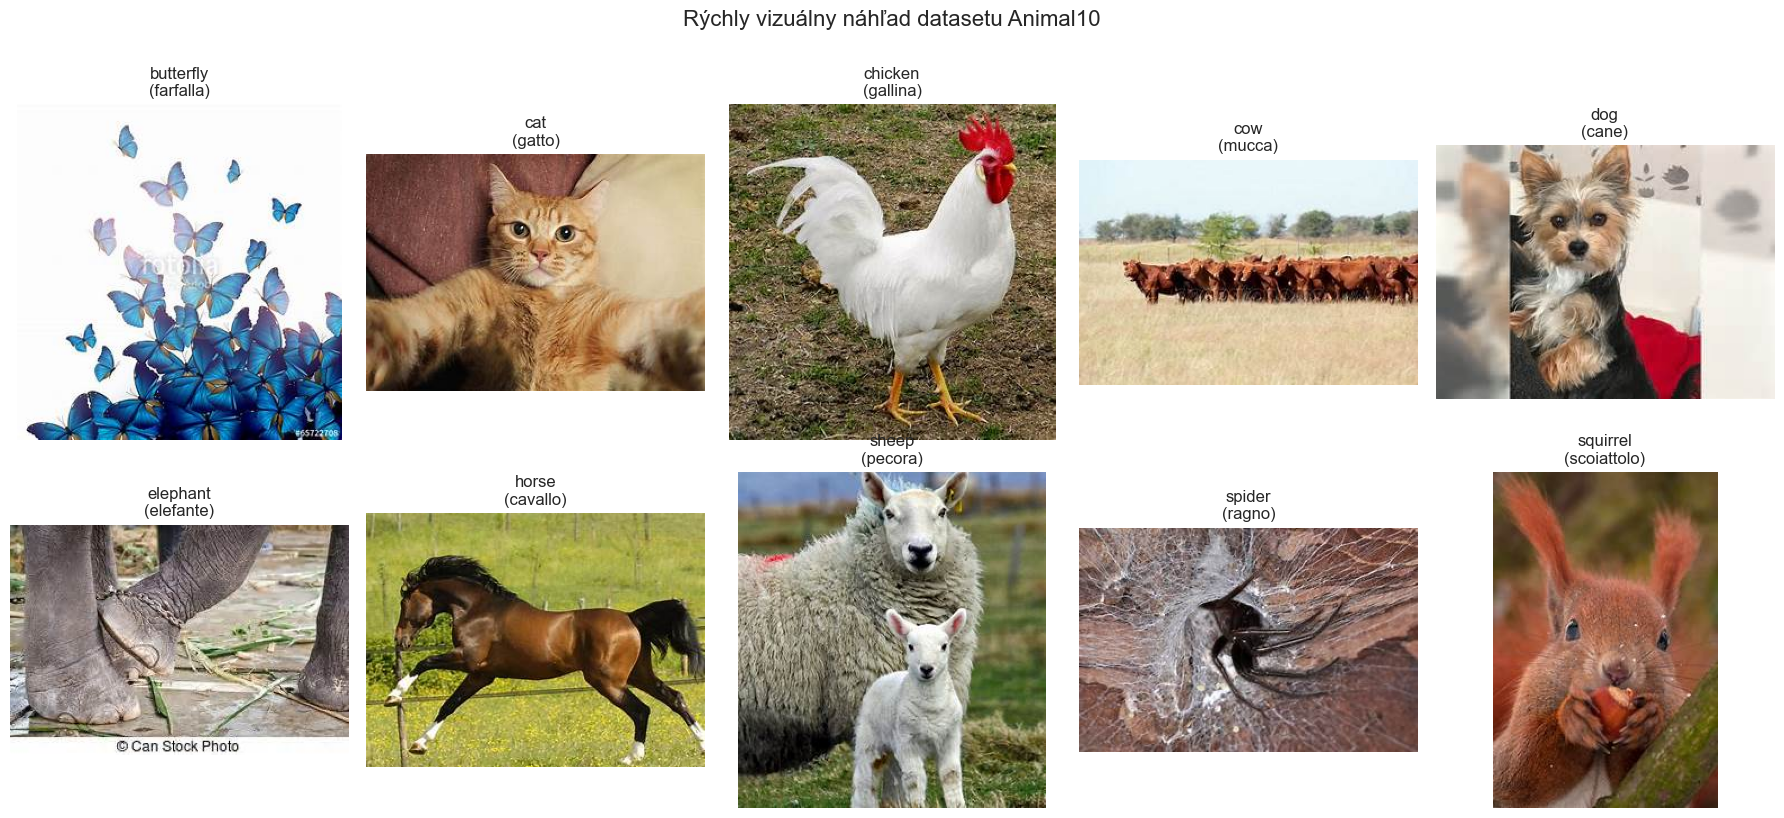

In [51]:
preview_rows = []

for class_name in class_dirs:
    class_path = DATA_ROOT / class_name
    image_files = sorted([p for p in class_path.iterdir() if p.is_file()])
    if image_files:
        preview_rows.append(
            {
                "class_it": class_name,
                "class_en": CLASS_TO_ENGLISH.get(class_name, class_name),
                "path": str(image_files[0]),
            }
        )

preview_df = pd.DataFrame(preview_rows).sort_values("class_en")

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, preview_df.iterrows()):
    with Image.open(row["path"]) as img:
        img = img.convert("RGB")
        ax.imshow(img)
    ax.set_title(f"{row['class_en']}\n({row['class_it']})")
    ax.axis("off")

plt.suptitle("Rýchly vizuálny náhľad datasetu Animal10", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


## 3. DF

V tejto bunke prejdeme všetky priečinky tried, načítame metadáta o obrázkoch a uložíme ich do tabuľky `df`.

Pre každý obrázok si uložíme:
- triedu v taliančine,
- preloženú triedu v angličtine,
- názov súboru a cestu,
- šírku, výšku, pomer strán a počet pixelov,
- formát a farebný mód,
- orientáciu obrázka.

Ak sa nejaký súbor nepodarí otvoriť, uloží sa do `bad_df`, aby sme vedeli odhaliť poškodené dáta.


In [52]:
records = []
bad_files = []

for class_dir in sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()]):
    for image_path in sorted([p for p in class_dir.iterdir() if p.is_file()]):
        try:
            with Image.open(image_path) as img:
                width, height = img.size
                image_format = img.format
                image_mode = img.mode

            records.append(
                {
                    "class_it": class_dir.name,
                    "class_en": CLASS_TO_ENGLISH.get(class_dir.name, class_dir.name),
                    "file_name": image_path.name,
                    "path": str(image_path),
                    "extension": image_path.suffix.lower(),
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height,
                    "pixels": width * height,
                    "format": image_format,
                    "mode": image_mode,
                    "orientation": "skoro_stvorec" if abs(width - height) <= 10 else ("na_sirku" if width > height else "na_vysku"),
                }
            )
        except Exception as exc:
            bad_files.append({"path": str(image_path), "error": repr(exc)})

df = pd.DataFrame(records)
bad_df = pd.DataFrame(bad_files)

print(f"Pocet tried: {df['class_it'].nunique()}")
print(f"Pocet nacitanych obrazkov: {len(df):,}")
print(f"Pocet necitatelnych suborov: {len(bad_df):,}")


Pocet tried: 10
Pocet nacitanych obrazkov: 26,179
Pocet necitatelnych suborov: 0


## 4. Základný prehľad datasetu

Teraz z pripraveného `DataFrame` vytvoríme základné sumáre:
- koľko je tried a obrázkov,
- koľko obrázkov pripadá na jednotlivé triedy,
- aká výrazná je nevyváženosť tried,
- či máme viac prípon, formátov alebo farebných módov.

Táto časť je dôležitá hlavne preto, aby sme ešte pred tréningom vedeli, či bude treba riešiť balancing alebo vhodnejšie metriky.


In [53]:
class_counts = (
    df.groupby(["class_it", "class_en"], as_index=False)
    .size()
    .rename(columns={"size": "images"})
    .sort_values("images", ascending=False)
)

overview = pd.DataFrame(
    {
        "metrika": [
            "pocet_tried",
            "pocet_obrazkov",
            "minimum_na_triedu",
            "maximum_na_triedu",
            "priemer_na_triedu",
            "median_na_triedu",
            "pomer_najvacsia_najmensia",
            "pocet_pripon",
            "pocet_formatov",
            "pocet_modov",
        ],
        "hodnota": [
            int(df["class_it"].nunique()),
            int(len(df)),
            int(class_counts["images"].min()),
            int(class_counts["images"].max()),
            round(class_counts["images"].mean(), 2),
            round(class_counts["images"].median(), 2),
            round(class_counts["images"].max() / class_counts["images"].min(), 2),
            int(df["extension"].nunique()),
            int(df["format"].nunique()),
            int(df["mode"].nunique()),
        ],
    }
)

display(Markdown("## Prehľad datasetu"))
display(overview)

display(Markdown("## Prvé riadky tabuľky"))
display(df.head())

display(Markdown("## Počet obrázkov v jednotlivých triedach"))
display(class_counts)

if not bad_df.empty:
    display(Markdown("## Problematické súbory"))
    display(bad_df.head())


## Prehľad datasetu

,metrika,hodnota
0,pocet_tried,10.00
1,pocet_obrazkov,26179.00
2,minimum_na_triedu,1446.00
3,maximum_na_triedu,4863.00
4,priemer_na_triedu,2617.90
5,median_na_triedu,1989.00
6,pomer_najvacsia_najmensia,3.36
7,pocet_pripon,3.00
8,pocet_formatov,2.00
9,pocet_modov,4.00


## Prvé riadky tabuľky

,class_it,class_en,file_name,path,extension,width,height,aspect_ratio,pixels,format,mode,orientation
0,cane,dog,OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg,dataset_utils/raw-img/cane/OIF-e2bexWrojgtQnAP...,.jpeg,300,225,1.333333,67500,JPEG,RGB,na_sirku
1,cane,dog,OIP---A27bIBcUgX1qkbpZOPswHaFS.jpeg,dataset_utils/raw-img/cane/OIP---A27bIBcUgX1qk...,.jpeg,300,214,1.401869,64200,JPEG,RGB,na_sirku
2,cane,dog,OIP---ZIdwfUcJeVxnh47zppcQHaFj.jpeg,dataset_utils/raw-img/cane/OIP---ZIdwfUcJeVxnh...,.jpeg,300,225,1.333333,67500,JPEG,RGB,na_sirku
3,cane,dog,OIP---ZRsOF7zsMqhW30WeF8-AHaFj.jpeg,dataset_utils/raw-img/cane/OIP---ZRsOF7zsMqhW3...,.jpeg,300,225,1.333333,67500,JPEG,RGB,na_sirku
4,cane,dog,OIP---_cJbI6Ei26w5bW1urHewHaCf.jpeg,dataset_utils/raw-img/cane/OIP---_cJbI6Ei26w5b...,.jpeg,300,101,2.970297,30300,JPEG,RGB,na_sirku


## Počet obrázkov v jednotlivých triedach

,class_it,class_en,images
0,cane,dog,4863
8,ragno,spider,4821
4,gallina,chicken,3098
1,cavallo,horse,2623
3,farfalla,butterfly,2112
6,mucca,cow,1866
9,scoiattolo,squirrel,1862
7,pecora,sheep,1820
5,gatto,cat,1668
2,elefante,elephant,1446


## 5. Vizualizácia tried, formátov a prípon

V tejto časti si graficky ukážeme:
- rozdelenie obrázkov medzi triedy,
- aké prípony súborov sa v datasete nachádzajú,
- v akých obrazových formátoch sú dáta uložené.

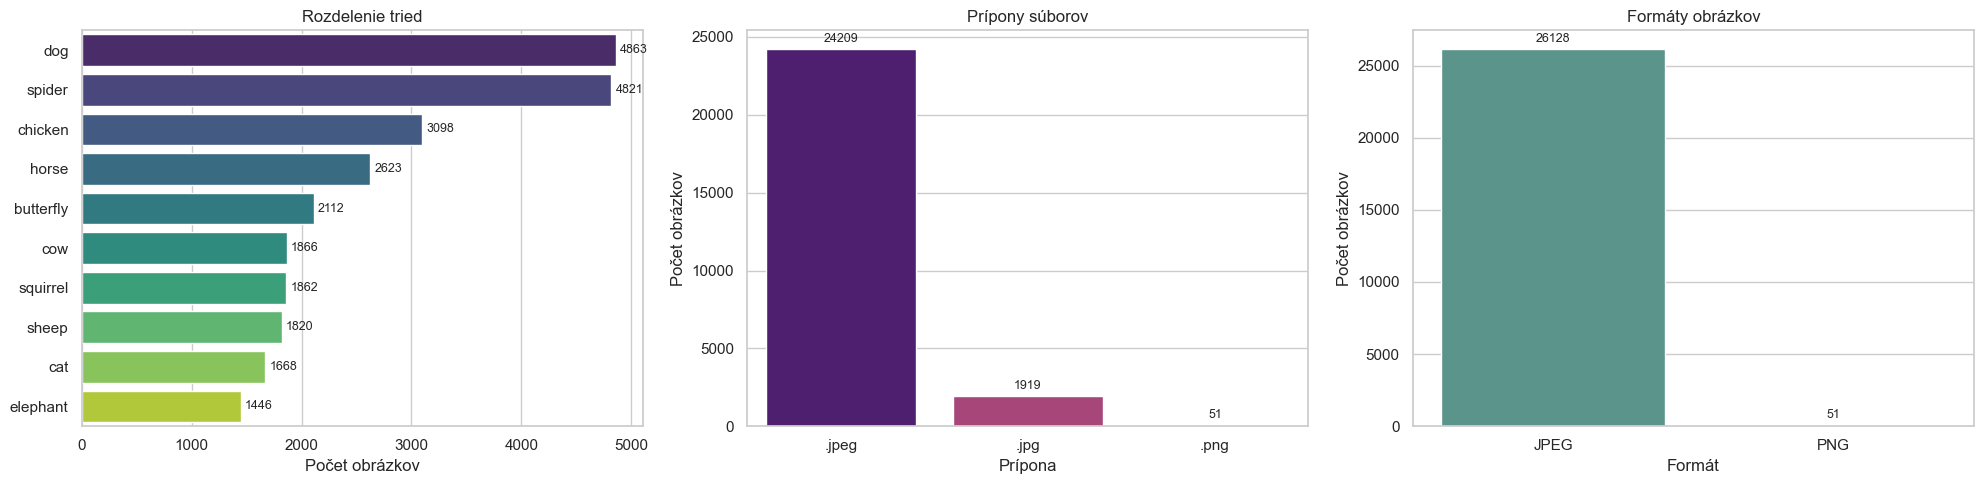

### Farebné módy

,mode,images
0,RGB,26128
1,RGBA,49
2,L,1
3,CMYK,1


In [54]:
format_counts = df["format"].value_counts().rename_axis("format").reset_index(name="images")
mode_counts = df["mode"].value_counts().rename_axis("mode").reset_index(name="images")
extension_counts = df["extension"].value_counts().rename_axis("extension").reset_index(name="images")

def add_bar_labels(ax, fmt="{:.0f}"):
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if pd.isna(value):
                labels.append("")
            else:
                labels.append(fmt.format(value))
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=class_counts, x="images", y="class_en", palette="viridis", ax=axes[0])
axes[0].set_title("Rozdelenie tried")
axes[0].set_xlabel("Počet obrázkov")
axes[0].set_ylabel("")
add_bar_labels(axes[0])

sns.barplot(data=extension_counts, x="extension", y="images", palette="magma", ax=axes[1])
axes[1].set_title("Prípony súborov")
axes[1].set_xlabel("Prípona")
axes[1].set_ylabel("Počet obrázkov")
add_bar_labels(axes[1])

sns.barplot(data=format_counts, x="format", y="images", palette="crest", ax=axes[2])
axes[2].set_title("Formáty obrázkov")
axes[2].set_xlabel("Formát")
axes[2].set_ylabel("Počet obrázkov")
add_bar_labels(axes[2])

plt.tight_layout()
plt.show()

display(Markdown("### Farebné módy"))
display(mode_counts)


## 6. Analýza rozmerov obrázkov

Keďže pri klasifikácii budeme obrázky neskôr resizeovať na fixný rozmer, potrebujeme vedieť, aká je aktuálna distribúcia šírok, výšok a pomerov strán.

Táto bunka zhrnie základné štatistiky a zároveň zobrazí histogramy a scatter plot `width vs. height` na vzorke dát.


,metrika,hodnota
0,width_min,60.000
1,width_max,6720.000
2,width_mean,320.040
3,width_median,300.000
4,height_min,57.000
5,height_max,6000.000
6,height_mean,252.630
7,height_median,225.000
8,aspect_ratio_min,0.293
9,aspect_ratio_max,4.225


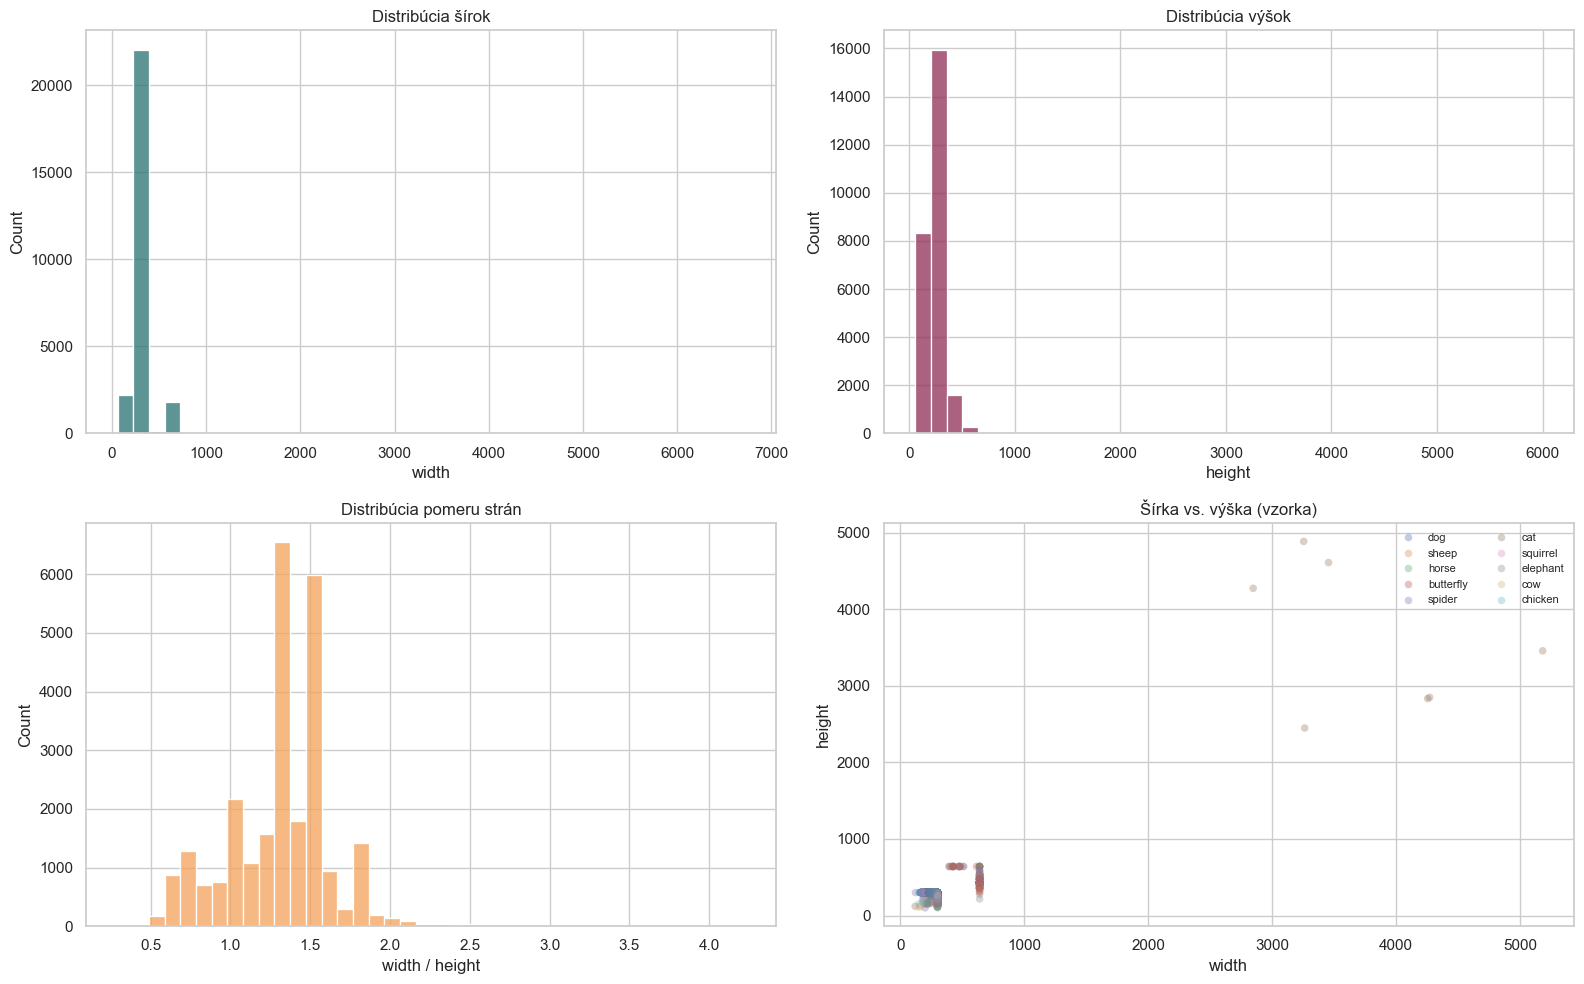

### Najčastejšie rozmery obrázkov

,width,height,images
0,300,225,4397
1,300,200,3281
2,300,300,1192
3,300,169,1048
4,640,426,694
5,300,199,586
6,225,300,490
7,300,240,403
8,300,188,393
9,200,300,362


In [55]:
size_summary = pd.DataFrame(
    {
        "metrika": [
            "width_min",
            "width_max",
            "width_mean",
            "width_median",
            "height_min",
            "height_max",
            "height_mean",
            "height_median",
            "aspect_ratio_min",
            "aspect_ratio_max",
            "aspect_ratio_mean",
            "pixels_median",
        ],
        "hodnota": [
            int(df["width"].min()),
            int(df["width"].max()),
            round(df["width"].mean(), 2),
            round(df["width"].median(), 2),
            int(df["height"].min()),
            int(df["height"].max()),
            round(df["height"].mean(), 2),
            round(df["height"].median(), 2),
            round(df["aspect_ratio"].min(), 3),
            round(df["aspect_ratio"].max(), 3),
            round(df["aspect_ratio"].mean(), 3),
            int(df["pixels"].median()),
        ],
    }
)

display(size_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df["width"], bins=40, color="#287271", ax=axes[0, 0])
axes[0, 0].set_title("Distribúcia šírok")

sns.histplot(df["height"], bins=40, color="#8f2d56", ax=axes[0, 1])
axes[0, 1].set_title("Distribúcia výšok")

sns.histplot(df["aspect_ratio"], bins=40, color="#f4a259", ax=axes[1, 0])
axes[1, 0].set_title("Distribúcia pomeru strán")
axes[1, 0].set_xlabel("width / height")

sample_for_scatter = df.sample(n=min(4000, len(df)), random_state=42)
sns.scatterplot(
    data=sample_for_scatter,
    x="width",
    y="height",
    hue="class_en",
    alpha=0.35,
    s=30,
    linewidth=0,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Šírka vs. výška (vzorka)")
axes[1, 1].legend(loc="upper right", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

display(Markdown("### Najčastejšie rozmery obrázkov"))
display(df[["width", "height"]].value_counts().head(15).rename("images").reset_index())


## 7. Orientácia obrázkov a rozdiely medzi triedami

Tu sa pozeráme na to, či sú obrázky častejšie orientované na šírku, na výšku alebo sú takmer štvorcové.

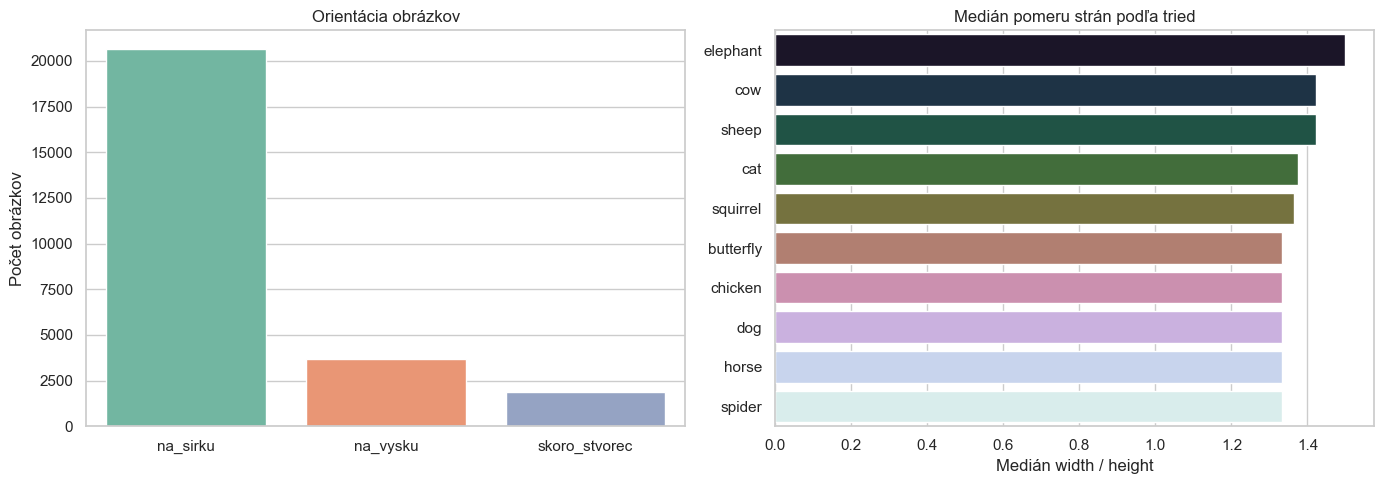

,orientation,images
0,na_sirku,20639
1,na_vysku,3658
2,skoro_stvorec,1882


,class_en,width,height,aspect_ratio
5,elephant,300.0,225.0,1.500000
3,cow,300.0,209.0,1.421801
7,sheep,300.0,225.0,1.421801
1,cat,300.0,243.5,1.376147
9,squirrel,300.0,217.0,1.363636
0,butterfly,300.0,230.0,1.333333
2,chicken,300.0,225.0,1.333333
4,dog,300.0,225.0,1.333333
6,horse,300.0,225.0,1.333333
8,spider,300.0,225.0,1.333333


In [56]:
orientation_counts = (
    df["orientation"].value_counts().rename_axis("orientation").reset_index(name="images")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=orientation_counts, x="orientation", y="images", palette="Set2", ax=axes[0])
axes[0].set_title("Orientácia obrázkov")
axes[0].set_xlabel("")
axes[0].set_ylabel("Počet obrázkov")

median_by_class = (
    df.groupby("class_en", as_index=False)[["width", "height", "aspect_ratio"]]
    .median()
    .sort_values("aspect_ratio", ascending=False)
)
sns.barplot(data=median_by_class, x="aspect_ratio", y="class_en", palette="cubehelix", ax=axes[1])
axes[1].set_title("Medián pomeru strán podľa tried")
axes[1].set_xlabel("Medián width / height")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(orientation_counts)
display(median_by_class)


## 8. Predpríprava dát pre modelovanie

V tejto sekcii pripravíme dataset do podoby, ktorú budeme vedieť rovno použiť pri tréningu modelov.

Bez ohľadu na to, aký model budeme testovať neskôr, je užitočné mať:
- jednotné ID tried,
- prehľadný manifest so všetkými metadátami,
- informáciu, ktoré obrázky treba pri načítaní previesť na `RGB`,
- stratifikovaný train/validation/test split,
- uložené CSV súbory, aby sme nemuseli split robiť nanovo pri každom notebooku alebo skripte.


In [57]:
import hashlib
from sklearn.model_selection import train_test_split

def file_md5(path, chunk_size=1024 * 1024):
    hasher = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            hasher.update(chunk)
    return hasher.hexdigest()

prepared_df = df.copy()
prepared_df["relative_path"] = prepared_df["path"].apply(lambda p: Path(p).as_posix())
prepared_df["needs_rgb_conversion"] = prepared_df["mode"] != "RGB"
prepared_df["content_hash"] = prepared_df["path"].apply(file_md5)

label_order = sorted(prepared_df["class_it"].unique())
label_to_id = {label: idx for idx, label in enumerate(label_order)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

prepared_df["target_id"] = prepared_df["class_it"].map(label_to_id)
prepared_df["split"] = "unassigned"

train_df, temp_df = train_test_split(
    prepared_df,
    test_size=0.30,
    random_state=42,
    stratify=prepared_df["class_it"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["class_it"],
)

prepared_df.loc[train_df.index, "split"] = "train"
prepared_df.loc[val_df.index, "split"] = "val"
prepared_df.loc[test_df.index, "split"] = "test"

duplicate_summary = (
    prepared_df.groupby("content_hash")
    .size()
    .rename("count")
    .reset_index()
    .query("count > 1")
    .sort_values("count", ascending=False)
)

split_summary = (
    prepared_df.groupby(["split", "class_en"], as_index=False)
    .size()
    .rename(columns={"size": "images"})
    .sort_values(["split", "class_en"])
)

prep_summary = pd.DataFrame(
    {
        "metrika": [
            "pocet_zaznamov_v_manifeste",
            "pocet_unikatnych_hashov",
            "pocet_hash_duplicit",
            "obrazky_mimo_RGB",
            "train_pocet",
            "val_pocet",
            "test_pocet",
        ],
        "hodnota": [
            int(len(prepared_df)),
            int(prepared_df["content_hash"].nunique()),
            int(len(duplicate_summary)),
            int(prepared_df["needs_rgb_conversion"].sum()),
            int((prepared_df["split"] == "train").sum()),
            int((prepared_df["split"] == "val").sum()),
            int((prepared_df["split"] == "test").sum()),
        ],
    }
)

artifacts_dir = Path("artifacts/animal10")
artifacts_dir.mkdir(parents=True, exist_ok=True)

prepared_df.to_csv(artifacts_dir / "animal10_manifest.csv", index=False)
prepared_df.query("split == 'train'").to_csv(artifacts_dir / "animal10_train.csv", index=False)
prepared_df.query("split == 'val'").to_csv(artifacts_dir / "animal10_val.csv", index=False)
prepared_df.query("split == 'test'").to_csv(artifacts_dir / "animal10_test.csv", index=False)
pd.DataFrame(
    {
        "class_it": label_order,
        "class_en": [CLASS_TO_ENGLISH[label] for label in label_order],
        "target_id": [label_to_id[label] for label in label_order],
    }
).to_csv(artifacts_dir / "animal10_label_mapping.csv", index=False)

display(Markdown("### Zhrnutie predprípravy"))
display(prep_summary)

display(Markdown("### Rozdelenie tried podľa splitu"))
display(split_summary)

if not duplicate_summary.empty:
    display(Markdown("### Potenciálne duplicitné obrázky podľa hash-u"))
    display(duplicate_summary.head(20))

display(Markdown(f"### Súbory uložené do `{artifacts_dir}`"))
display(sorted([p.name for p in artifacts_dir.iterdir() if p.is_file()]))


### Zhrnutie predprípravy

,metrika,hodnota
0,pocet_zaznamov_v_manifeste,26179
1,pocet_unikatnych_hashov,26179
2,pocet_hash_duplicit,0
3,obrazky_mimo_RGB,51
4,train_pocet,18325
5,val_pocet,3927
6,test_pocet,3927


### Rozdelenie tried podľa splitu

,split,class_en,images
0,test,butterfly,317
1,test,cat,250
2,test,chicken,465
3,test,cow,280
4,test,dog,730
...,...,...,...
25,val,elephant,217
26,val,horse,394
27,val,sheep,273
28,val,spider,723


### Súbory uložené do `artifacts/animal10`

['animal10_label_mapping.csv',
 'animal10_manifest.csv',
 'animal10_test.csv',
 'animal10_train.csv',
 'animal10_val.csv']

## 9. Pipeline

Táto pipeline nerobí nevratné zmeny do súborov na disku. Transformácie sa aplikujú až pri načítaní dát, čo je výhodné, lebo ich vieme neskôr ľahko meniť.

Základné kroky sú:
- prevod na `RGB`, aby mali všetky obrázky rovnaký počet kanálov,
- resize na trochu väčší rozmer a následný crop na `224x224`,
- prevod na tensor,
- normalizácia pixelov.


In [58]:
import torch
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
INPUT_SIZE = 224
RESIZE_SIZE = 256

train_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(RESIZE_SIZE),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(RESIZE_SIZE),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

sample_row = prepared_df.iloc[0]
with Image.open(sample_row["path"]) as sample_img:
    sample_tensor = eval_transforms(sample_img)

pipeline_summary = pd.DataFrame(
    {
        "krok": [
            "convert_to_rgb",
            "resize",
            "center_crop",
            "to_tensor",
            "normalize",
        ],
        "popis": [
            "zjednotenie počtu kanálov na 3",
            f"kratšia strana sa upraví na približne {RESIZE_SIZE} px",
            f"výsledný vstup do modelu bude {INPUT_SIZE}x{INPUT_SIZE}",
            "obrázok sa prevedie na tensor tvaru C x H x W",
            "normalizácia podľa ImageNet mean/std",
        ],
    }
)

display(Markdown("### Navrhovaná pipeline"))
display(pipeline_summary)

print("Ukážkový tensor po transformácii:")
print("shape:", tuple(sample_tensor.shape))
print("dtype:", sample_tensor.dtype)
print("min:", float(sample_tensor.min()))
print("max:", float(sample_tensor.max()))


### Navrhovaná pipeline

,krok,popis
0,convert_to_rgb,zjednotenie počtu kanálov na 3
1,resize,kratšia strana sa upraví na približne 256 px
2,center_crop,výsledný vstup do modelu bude 224x224
3,to_tensor,obrázok sa prevedie na tensor tvaru C x H x W
4,normalize,normalizácia podľa ImageNet mean/std


Ukážkový tensor po transformácii:
shape: (3, 224, 224)
dtype: torch.float32
min: -2.0836544036865234
max: 2.517995834350586


In [59]:
load_dotenv()
os.environ["WANDB_API_KEY"] = os.getenv('WANDB_API_KEY')

wandb.login()

True

In [60]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

torch.backends.cudnn.benchmark = True

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
DEVICE

'mps'

In [61]:
ARTIFACTS_DIR = Path("artifacts/animal10")

train_csv = ARTIFACTS_DIR / "animal10_train.csv"
val_csv   = ARTIFACTS_DIR / "animal10_val.csv"
test_csv  = ARTIFACTS_DIR / "animal10_test.csv"

train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print(len(train_df), len(val_df), len(test_df))
train_df.head()

18325 3927 3927


,class_it,class_en,file_name,path,extension,width,height,aspect_ratio,pixels,format,mode,orientation,relative_path,needs_rgb_conversion,content_hash,target_id,split
0,cane,dog,OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg,dataset_utils/raw-img/cane/OIF-e2bexWrojgtQnAP...,.jpeg,300,225,1.333333,67500,JPEG,RGB,na_sirku,dataset_utils/raw-img/cane/OIF-e2bexWrojgtQnAP...,False,fda3a63b57bb6bdf0b1af8ec110310be,0,train
1,cane,dog,OIP---A27bIBcUgX1qkbpZOPswHaFS.jpeg,dataset_utils/raw-img/cane/OIP---A27bIBcUgX1qk...,.jpeg,300,214,1.401869,64200,JPEG,RGB,na_sirku,dataset_utils/raw-img/cane/OIP---A27bIBcUgX1qk...,False,1d5e33460ed7a824f7c29e305fb81c94,0,train
2,cane,dog,OIP---ZIdwfUcJeVxnh47zppcQHaFj.jpeg,dataset_utils/raw-img/cane/OIP---ZIdwfUcJeVxnh...,.jpeg,300,225,1.333333,67500,JPEG,RGB,na_sirku,dataset_utils/raw-img/cane/OIP---ZIdwfUcJeVxnh...,False,c3331f98db767ea625165b4accf78261,0,train
3,cane,dog,OIP--0C2kq6I68beB3DduLoxMgHaEf.jpeg,dataset_utils/raw-img/cane/OIP--0C2kq6I68beB3D...,.jpeg,300,182,1.648352,54600,JPEG,RGB,na_sirku,dataset_utils/raw-img/cane/OIP--0C2kq6I68beB3D...,False,b6b0671ef86c8a43c709969abf8bdbaf,0,train
4,cane,dog,OIP--0CZnfLuBERVtzRm2QbB3gHaK4.jpeg,dataset_utils/raw-img/cane/OIP--0CZnfLuBERVtzR...,.jpeg,205,300,0.683333,61500,JPEG,RGB,na_vysku,dataset_utils/raw-img/cane/OIP--0CZnfLuBERVtzR...,False,6025cd534fa3cd741ab032f922c51a75,0,train


In [62]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
INPUT_SIZE = 224
RESIZE_SIZE = 256
NUM_CLASSES = train_df["target_id"].nunique()


In [63]:
def build_transforms(augmented: bool, aug_prob: float):
    if augmented:
        train_tfms = transforms.Compose([
            transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
            transforms.RandomApply(
                [
                    transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
                    transforms.RandomHorizontalFlip(p=1.0),
                    transforms.RandomRotation(degrees=15),
                    transforms.ColorJitter(
                        brightness=0.2,
                        contrast=0.2,
                        saturation=0.2,
                        hue=0.03,
                    ),
                    transforms.RandomAffine(
                        degrees=0,
                        translate=(0.08, 0.08),
                        scale=(0.95, 1.05),
                    ),
                    transforms.RandomPerspective(distortion_scale=0.15, p=0.5),
                ],
                p=aug_prob,  
            ),
            transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3)),
        ])
    else:
        train_tfms = transforms.Compose([
            transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    eval_tfms = transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    return train_tfms, eval_tfms

In [64]:
def make_weighted_sampler(df: pd.DataFrame):
    class_counts = df["target_id"].value_counts().sort_index()
    class_weights = 1.0 / class_counts
    sample_weights = df["target_id"].map(class_weights).values
    sample_weights = torch.DoubleTensor(sample_weights)
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

def build_loaders(
    train_df,
    val_df,
    test_df,
    num_workers,
    aug_prob,
    batch_size,
    augmented=True,
    use_weighted_sampler=False,
):
    train_tfms, eval_tfms = build_transforms(augmented=augmented, aug_prob=aug_prob)

    train_ds = Animal10Dataset(train_df, transform=train_tfms)
    val_ds   = Animal10Dataset(val_df, transform=eval_tfms)
    test_ds  = Animal10Dataset(test_df, transform=eval_tfms)

    sampler = make_weighted_sampler(train_df) if use_weighted_sampler else None

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=(sampler is None),
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=(DEVICE == "cuda"),
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(DEVICE == "cuda"),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(DEVICE == "cuda"),
    )
    return train_loader, val_loader, test_loader

In [65]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class DeepCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [66]:

def freeze_all_but_classifier(model, classifier_keywords=("fc", "classifier")):
    for name, param in model.named_parameters():
        param.requires_grad = False
        for kw in classifier_keywords:
            if kw in name:
                param.requires_grad = True
                break
    return model

In [67]:
def build_model(model_name: str, num_classes: int, pretrained: bool = True, freeze_backbone: bool = False):
    if model_name == "small_cnn":
        model = SmallCNN(num_classes=num_classes)

    elif model_name == "deep_cnn":
        model = DeepCNN(num_classes=num_classes)

    elif model_name == "resnet18_transfer":
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        if freeze_backbone:
            model = freeze_all_but_classifier(model, classifier_keywords=("fc",))
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return model

In [68]:
def build_optimizer(model, optimizer_name="adamw", lr=1e-3, weight_decay=1e-4):
    params = [p for p in model.parameters() if p.requires_grad]

    if optimizer_name.lower() == "adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "adamw":
        return optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "sgd":
        return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

def build_scheduler(optimizer, scheduler_name="cosine", epochs=10):
    if scheduler_name is None or scheduler_name == "none":
        return None
    elif scheduler_name == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif scheduler_name == "step":
        return optim.lr_scheduler.StepLR(optimizer, step_size=max(epochs // 3, 1), gamma=0.1)
    else:
        raise ValueError(f"Unknown scheduler: {scheduler_name}")

In [69]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds = []
    all_targets = []
    all_probs = []

    for images, targets in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, targets)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro")

    roc_auc = None
    try:
        roc_auc = roc_auc_score(
            all_targets,
            np.array(all_probs),
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        pass

    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "f1_macro": epoch_f1,
        "roc_auc_ovr_macro": roc_auc,
        "preds": np.array(all_preds),
        "targets": np.array(all_targets),
        "probs": np.array(all_probs),
    }

In [70]:
def train_experiment(config):
    set_seed(config.get("seed", 42))
    epochs_without_improvement = 0
    patience = config["patience"]

    train_loader, val_loader, test_loader = build_loaders(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        batch_size=config["batch_size"],
        aug_prob = config["aug_prob"],
        num_workers=config.get("num_workers"),
        augmented=config["augmented"],
        use_weighted_sampler=config.get("use_weighted_sampler", False),
    )

    model = build_model(
        model_name=config["model_name"],
        num_classes=NUM_CLASSES,
        pretrained=config.get("pretrained", True),
        freeze_backbone=config.get("freeze_backbone", False),
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(label_smoothing=config.get("label_smoothing", 0.0))
    optimizer = build_optimizer(
        model=model,
        optimizer_name=config["optimizer"],
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    scheduler = build_scheduler(
        optimizer=optimizer,
        scheduler_name=config.get("scheduler", "cosine"),
        epochs=config["epochs"],
    )

    run_name = config.get("run_name")
    project_name = config.get("project")

    with wandb.init(
        project=project_name,
        entity="lui-vitarius-slovak-university-of-technology",
        config=config,
        name=run_name,
    ) as run:
        # wandb.watch(model, log="gradients", log_freq=100)

        best_val_f1 = -1.0
        best_ckpt_path = Path("checkpoints")
        best_ckpt_path.mkdir(exist_ok=True)
        best_ckpt_file = best_ckpt_path / f"{run.name}_best.pt"

        for epoch in range(1, config["epochs"] + 1):
            print("Running train epoch")
            train_metrics = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
            
            print("Running val epoch")
            val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None)

            current_lr = optimizer.param_groups[0]["lr"]

            wandb.log({
                "epoch": epoch,
                "lr": current_lr,
                "train/loss": train_metrics["loss"],
                "train/acc": train_metrics["acc"],
                "train/f1_macro": train_metrics["f1_macro"],
                "val/loss": val_metrics["loss"],
                "val/acc": val_metrics["acc"],
                "val/f1_macro": val_metrics["f1_macro"],
            })

            if scheduler is not None:
                scheduler.step()

            if val_metrics["f1_macro"] > best_val_f1:
                best_val_f1 = val_metrics["f1_macro"]
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "config": dict(config),
                        "best_val_f1": best_val_f1,
                    },
                    best_ckpt_file,
                )
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        checkpoint = torch.load(best_ckpt_file, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])

        test_metrics = run_one_epoch(model, test_loader, criterion, optimizer=None)

        cm = confusion_matrix(test_metrics["targets"], test_metrics["preds"])
        cls_report = classification_report(
            test_metrics["targets"],
            test_metrics["preds"],
            output_dict=True,
            zero_division=0,
        )
        cls_report_df = pd.DataFrame(cls_report).T

        wandb.log({
            "best_val_f1": best_val_f1,
            "test/loss": test_metrics["loss"],
            "test/acc": test_metrics["acc"],
            "test/f1_macro": test_metrics["f1_macro"],
        })

        class_names = [id_to_label[i] for i in range(NUM_CLASSES)]
        wandb.log({
            "test/confusion_matrix": wandb.plot.confusion_matrix(
                probs=None,
                y_true=test_metrics["targets"],
                preds=test_metrics["preds"],
                class_names=class_names,
            )
        })

        wandb.log({
            "test/classification_report": wandb.Table(dataframe=cls_report_df.reset_index())
        })

        wandb.save(str(best_ckpt_file))

        print(f"Run: {run.name}")
        print(f"Best val f1: {best_val_f1:.4f}")
        print(f"Test acc: {test_metrics['acc']:.4f}")
        print(f"Test f1_macro: {test_metrics['f1_macro']:.4f}")

        return {
            "run_name": run.name,
            "best_val_f1": best_val_f1,
            "test_acc": test_metrics["acc"],
            "test_f1_macro": test_metrics["f1_macro"],
            "checkpoint": str(best_ckpt_file),
        }

In [71]:
experiments = [
    {
        "run_name": "smallcnn_baseline_longer",
        "project": "NSIETE_Animal10",
        "model_name": "small_cnn",
        "pretrained": False,
        "freeze_backbone": False,
        "epochs": 80,
        "batch_size": 128,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "augmented": False,
        "use_weighted_sampler": False,
        "label_smoothing": 0.0,
        "seed": 42,
        "num_workers": 4,
        "patience": 20,
    },
    {
        "run_name": "smallcnn_augmented_longer",
        "project": "NSIETE_Animal10",
        "model_name": "small_cnn",
        "pretrained": False,
        "freeze_backbone": False,
        "epochs": 80,
        "batch_size": 192,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "augmented": True,
        "use_weighted_sampler": False,
        "label_smoothing": 0.05,
        "seed": 42,
        "num_workers": 4,
        "patience": 20,
    },
    {
        "run_name": "deepcnn_augmented",
        "project": "NSIETE_Animal10",
        "model_name": "deep_cnn",
        "pretrained": False,
        "freeze_backbone": False,
        "epochs": 80,
        "batch_size": 128,
        "lr": 7e-4,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "augmented": True,
        "use_weighted_sampler": False,
        "label_smoothing": 0.05,
        "seed": 42,
        "num_workers": 4,
        "patience": 20,
    },
    {
        "run_name": "resnet18_frozen_head",
        "project": "NSIETE_Animal10",
        "model_name": "resnet18_transfer",
        "pretrained": True,
        "freeze_backbone": True,
        "epochs": 50,
        "batch_size": 128,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "augmented": True,
        "use_weighted_sampler": False,
        "label_smoothing": 0.05,
        "seed": 42,
        "num_workers": 4,
        "patience": 15,
    },
    {
        "run_name": "deepcnn_augmented_stronger",
        "project": "NSIETE_Animal10",
        "model_name": "deep_cnn",
        "pretrained": False,
        "freeze_backbone": False,
        "epochs": 80,
        "batch_size": 128,
        "lr": 7e-4,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "augmented": True,
        "aug_prob": 0.9,
        "use_weighted_sampler": False,
        "label_smoothing": 0.05,
        "seed": 42,
        "num_workers": 4,
        "patience": 20,
    },
    {
        "run_name": "resnet18_finetune",
        "project": "NSIETE_Animal10",
        "model_name": "resnet18_transfer",
        "pretrained": True,
        "freeze_backbone": False,
        "epochs": 25,
        "batch_size": 128,
        "lr": 3e-4,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "augmented": True,
        "aug_prob": 0.9,
        "use_weighted_sampler": False,
        "label_smoothing": 0.05,
        "seed": 42,
        "num_workers": 4,
        "patience": 6,
    },
]

In [ ]:
results = []

for cfg in experiments[4:]:
    result = train_experiment(cfg)
    results.append(result)

results_df = pd.DataFrame(results).sort_values(
    ["test_f1_macro", "test_acc"], ascending=False
).reset_index(drop=True)
  
results_df

wandb: setting up run z0lu9tgb
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /Users/romankosik/PycharmProjects/Neuronove_siete/wandb/run-20260410_160905-z0lu9tgb
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run deepcnn_augmented_stronger
wandb: ⭐️ View project at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_Animal10
wandb: 🚀 View run at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_Animal10/runs/z0lu9tgb


Running train epoch


Running val epoch


Running train epoch


 53%|█████▎    | 76/144 [01:21<01:06,  1.02it/s]